# Movie Recommendation System

The goal is to recommend movies that are similar to a movie the user likes, using only the content of the movies (a content-based recommender): the plot summary, the keywords, the cast and the director. The data is the TMDB 5000 movies dataset (`tmdb_5000_movies.csv` and `tmdb_5000_credits.csv`, 4,803 movies).

Reference solution: [Movie Recommendation System with Machine Learning](https://amanxai.com/2020/05/20/data-science-project-movie-recommendation-system/) (Aman Kharwal). Data: [tmdb_5000_movies.csv](https://amanxai.com/wp-content/uploads/2020/05/tmdb_5000_movies.csv) and [tmdb_5000_credits.csv](https://amanxai.com/wp-content/uploads/2020/05/tmdb_5000_credits.csv).

The reference turns the plot summaries into TF-IDF vectors, computes a sigmoid kernel between all movies and prints the ten most similar titles of one example. It never measures whether the recommendations are good, and its code fails for some readers (see the comments of the article). This notebook adds a numeric check of the recommendations and compares a few variants.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, sigmoid_kernel
import os
os.chdir('/mnt/c/Users/myama/OneDrive/Belgeler/ai-1/Assignments/14-Specialize in Data Science/Recommendation Systems/movie_recommendation_system')

## Data Loading

In [2]:
movies = pd.read_csv("tmdb_5000_movies.csv")
credits = pd.read_csv("tmdb_5000_credits.csv")
print(movies.shape, credits.shape)
movies[["title", "genres", "keywords", "overview", "vote_average", "vote_count"]].head(3)

(4803, 20) (4803, 4)


,title,genres,keywords,overview,vote_average,vote_count
0,Avatar,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","In the 22nd century, a paraplegic Marine is di...",7.2,11800
1,Pirates of the Caribbean: At World's End,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","Captain Barbossa, long believed to be dead, ha...",6.9,4500
2,Spectre,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",A cryptic message from Bond’s past sends him o...,6.3,4466


## Data Cleaning

The two files are joined on the movie id. The credits file also has a `title` column, which is dropped before the join to avoid two columns with the same name. Some columns hold lists written as JSON text (`genres`, `keywords`, `cast`, `crew`).

In [3]:
df = movies.merge(credits.rename(columns={"movie_id": "id"})[["id", "cast", "crew"]], on="id")
print("missing values:", df[["overview", "genres", "keywords", "cast", "crew"]].isnull().sum().to_dict())
print("duplicated titles:", df["title"].duplicated().sum(), "| titles different from the original title:", (df["title"] != df["original_title"]).sum())

missing values: {'overview': 3, 'genres': 0, 'keywords': 0, 'cast': 0, 'crew': 0}
duplicated titles: 3 | titles different from the original title: 261


Three movies have no overview. The reference passes the overview column to the vectorizer as it is, which fails with `np.nan is an invalid document` (the error reported in its comments). Those movies are kept with an empty text, so that the other information can still be used. The reference also looks movies up by `original_title`, which is not in English for 400 movies and can be duplicated; the English `title` is used here.

In [4]:
df["overview"] = df["overview"].fillna("")
df = df.drop_duplicates(subset="title").reset_index(drop=True)

names = lambda text, n=None: [item["name"] for item in json.loads(text)][:n]
df["genre_list"] = df["genres"].apply(names)
df["keyword_list"] = df["keywords"].apply(names)
df["cast_list"] = df["cast"].apply(lambda text: names(text, 3))
df["director"] = df["crew"].apply(lambda text: [item["name"] for item in json.loads(text) if item["job"] == "Director"][:1])
df.shape

(4800, 26)

## Exploratory Data Analysis

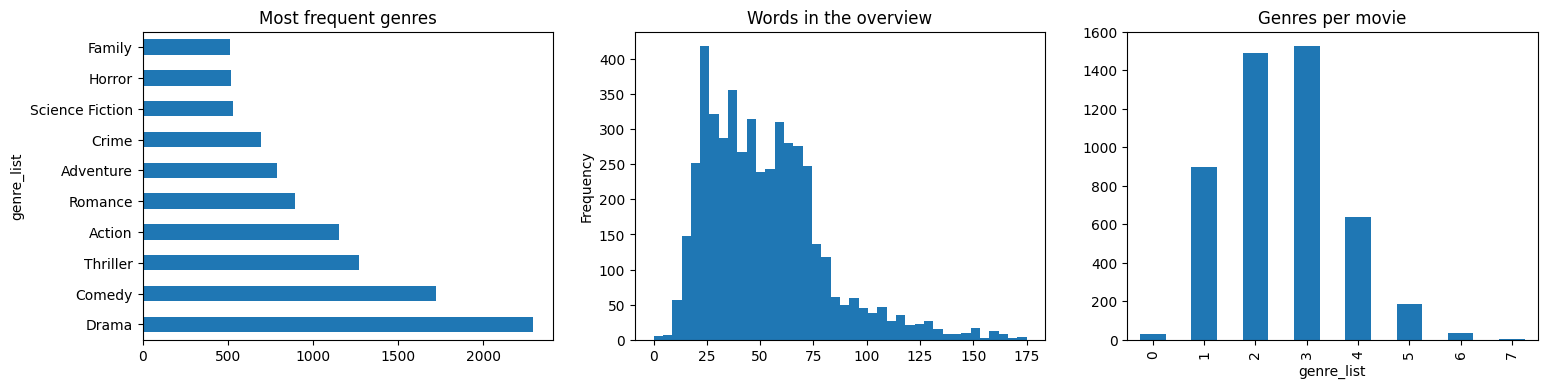

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
df["genre_list"].explode().value_counts().head(10).plot(kind="barh", ax=axes[0], title="Most frequent genres")
df["overview"].str.split().str.len().plot(kind="hist", bins=40, ax=axes[1], title="Words in the overview")
df["genre_list"].str.len().value_counts().sort_index().plot(kind="bar", ax=axes[2], title="Genres per movie")
plt.show()

Movies have 2 to 3 genres on average, and the overview has about 50 words. A short text gives few words to compare, which limits a recommender that uses only the overview.

## Reference Reproduction

The reference builds TF-IDF vectors of the overviews (words and sequences of up to three words, words in at least 3 movies, English stop words removed) and a sigmoid kernel between all pairs of movies.

In [6]:
tfidf = TfidfVectorizer(min_df=3, strip_accents="unicode", analyzer="word", token_pattern=r"\w{1,}", ngram_range=(1, 3), stop_words="english")
overview_matrix = tfidf.fit_transform(df["overview"])
print("matrix shape:", overview_matrix.shape)

sigmoid = sigmoid_kernel(overview_matrix, overview_matrix)
index = pd.Series(df.index, index=df["title"])

def recommend(title, similarity, n=10):
    scores = similarity[index[title]].copy()
    scores[index[title]] = -np.inf
    return df["title"].iloc[np.argsort(-scores)[:n]].tolist()

recommend("Avatar", sigmoid)

matrix shape: (4800, 10409)


['The Inhabited Island',
 'The Matrix',
 'Apollo 18',
 'The American',
 'Supernova',
 'Tears of the Sun',
 'Beowulf',
 'The Adventures of Pluto Nash',
 'Semi-Pro',
 'The Book of Life']

## Evaluation

There is no rating of the recommendations, so a proxy is used: a good recommendation should share genres with the movie it is recommended for. For every movie, the genre overlap (Jaccard index: shared genres divided by all genres of the two movies) between the movie and each of its ten recommendations is computed, and averaged over all 4,700 movies. The genres are never used to build the overview and the metadata representations below, so the check is not circular. Random recommendations and the ten most voted movies serve as baselines.

In [7]:
genres = pd.get_dummies(df["genre_list"].explode()).groupby(level=0).sum().reindex(df.index, fill_value=0).values
shared = genres @ genres.T
jaccard = shared / (genres.sum(axis=1)[:, None] + genres.sum(axis=1)[None, :] - shared).clip(min=1)

def genre_overlap(similarity, n=10):
    scores = similarity.copy()
    np.fill_diagonal(scores, -np.inf)
    top = np.argsort(-scores, axis=1)[:, :n]
    return {"mean genre overlap": np.take_along_axis(jaccard, top, axis=1).mean(),
            "share with at least one common genre": (np.take_along_axis(shared, top, axis=1) > 0).mean()}

Three text representations are compared besides the reference: the same overview vectors with the cosine similarity instead of the sigmoid kernel (the ranking should be identical, because the TF-IDF vectors have unit length and the sigmoid is an increasing function), single words only, and a "metadata" text that adds the keywords, the three first actors and the director to the overview.

In [8]:
df["metadata"] = df["overview"] + " " + df["keyword_list"].apply(lambda words: " ".join(w.replace(" ", "") for w in words)) \
                 + " " + df["cast_list"].apply(lambda words: " ".join(w.replace(" ", "") for w in words)) \
                 + " " + df["director"].apply(lambda words: " ".join(w.replace(" ", "") for w in words))

similarities = {
    "Overview, sigmoid kernel (reference)": sigmoid,
    "Overview, cosine": cosine_similarity(overview_matrix),
    "Overview, single words, cosine": cosine_similarity(TfidfVectorizer(min_df=3, stop_words="english").fit_transform(df["overview"])),
    "Overview + keywords + cast + director, cosine": cosine_similarity(TfidfVectorizer(min_df=3, stop_words="english").fit_transform(df["metadata"])),
    "Random": np.random.default_rng(42).random(jaccard.shape),
    "Ten most voted movies for everyone": np.tile(df["vote_count"].values, (len(df), 1)).astype(float),
}

pd.DataFrame({name: genre_overlap(similarity) for name, similarity in similarities.items()}).T.round(3)

,mean genre overlap,share with at least one common genre
"Overview, sigmoid kernel (reference)",0.267,0.647
"Overview, cosine",0.267,0.647
"Overview, single words, cosine",0.267,0.647
"Overview + keywords + cast + director, cosine",0.308,0.702
Random,0.168,0.495
Ten most voted movies for everyone,0.144,0.479


In [9]:
top_sigmoid = np.argsort(-np.where(np.eye(len(df), dtype=bool), -np.inf, similarities["Overview, sigmoid kernel (reference)"]), axis=1)[:, :10]
top_cosine = np.argsort(-np.where(np.eye(len(df), dtype=bool), -np.inf, similarities["Overview, cosine"]), axis=1)[:, :10]
print("share of identical top-10 lists, sigmoid kernel against cosine:", (top_sigmoid == top_cosine).all(axis=1).mean().round(3))

share of identical top-10 lists, sigmoid kernel against cosine: 1.0


In [10]:
similarity = similarities["Overview + keywords + cast + director, cosine"]
for title in ["Avatar", "The Dark Knight Rises", "Toy Story"]:
    print(title, "->", recommend(title, similarity, 5))

Avatar -> ['Aliens', 'Falcon Rising', 'Battle: Los Angeles', 'Apollo 18', 'Titan A.E.']
The Dark Knight Rises -> ['The Dark Knight', 'Batman Returns', 'Batman Forever', 'Batman Begins', 'Batman']
Toy Story -> ['Toy Story 3', 'Toy Story 2', 'The 40 Year Old Virgin', 'Factory Girl', 'Class of 1984']


The three overview-only versions reach the same genre overlap (0.267): the sigmoid kernel of the reference gives exactly the same ten recommendations as the cosine similarity for every movie (100% identical lists), because the TF-IDF vectors have unit length and the sigmoid is an increasing function, so it only adds computation. Using single words instead of sequences of up to three words changes the genre overlap by less than 0.001.

All text-based versions are clearly better than random recommendations (0.267 against 0.168; 65% of the recommendations share at least one genre, against 50% for random) and than the most voted movies (0.144), so the overview does carry information. Adding the keywords, the three first actors and the director raises the genre overlap to 0.308 (70% with a common genre): keywords and people describe a movie better than a 50-word plot summary. The examples show what this means in practice: for "The Dark Knight Rises" the results are the other Batman movies, and for "Toy Story" the first two suggestions are its sequels, but the following ones ("The 40 Year Old Virgin", "Factory Girl") show that plot words alone can also link unrelated movies.

## Conclusion

**Reference approach.** The reference builds TF-IDF vectors from the movie overviews, computes a sigmoid kernel between all pairs and prints the ten most similar titles for one movie. It reports no measure of quality. Its code breaks on movies without an overview (`np.nan is an invalid document`, reported by several readers), it looks movies up by `original_title` (not in English for 261 movies), and a comment in the article calls the method "supervised", although a content-based recommender uses no labels.

**Our approach.** The missing overviews were filled with an empty text and the English `title` was used. Since no rating of the recommendations exists, the genre overlap between a movie and its ten recommendations (Jaccard index, average over 4,800 movies) was used as a proxy that does not use the genres as an input:

| Method | Genre overlap | Recommendations with a common genre |
|---|---|---|
| Overview, sigmoid kernel (reference) | 0.267 | 64.7% |
| Overview, cosine | 0.267 | 64.7% |
| Overview, single words, cosine | 0.267 | 64.7% |
| Overview + keywords + cast + director, cosine | 0.308 | 70.2% |
| Random | 0.168 | 49.5% |
| Ten most voted movies | 0.144 | 47.9% |

The sigmoid kernel of the reference gives the same ranking as the cosine similarity for every movie, so it can be replaced by the simpler and faster cosine. Recommendations based on the plot text are better than random, and they get better when keywords, actors and director are added.

**Limitations.** Genre overlap is only a proxy: two movies can be good recommendations for each other without sharing a genre, and sharing a genre does not make a movie a good recommendation. The real quality would have to be measured with user ratings or clicks, which this dataset does not have. The metadata version relies on the first three actors and the director only. A recommender based on content cannot use the tastes of other users, which the collaborative methods of the next projects do.